## 1. Load the Iris Dataset

In [1]:
import pandas as pd

# Load the Iris Dataset from the provided CSV file path
csv_file_path = '/content/drive/MyDrive/AI LAB/AI LAB3/Iris.csv'
df = pd.read_csv(csv_file_path)

print("Iris Dataset loaded successfully.")
display(df.head())

Iris Dataset loaded successfully.


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Identify and Document Dataset Characteristics

In [3]:
# 2.1 Number of records and features
num_records, num_features = df.shape
print(f"Number of records: {num_records}")
print(f"Number of features: {num_features}")

# 2.2 Feature names
feature_names = df.columns.tolist()
print(f"Feature names: {feature_names}")

# 2.3 Data types
print("\nData types of features:")
print(df.dtypes)

# 2.4 Target/class variable
# In the Iris dataset, 'Species' is the target/class variable in this loaded CSV.
# We will explicitly set it to 'Species' as observed in the dataframe head.
target_variable = 'Species'

if target_variable in df.columns:
    print(f"\nTarget/Class variable: {target_variable}")
    print("Unique classes in target variable:")
    print(df[target_variable].unique())
else:
    print(f"\nError: The specified target variable '{target_variable}' was not found in the DataFrame columns.")
    target_variable = None # Set to None if not found, to avoid errors later if used.

# 2.5 Basic statistical information
print("\nBasic statistical information for numerical features:")
display(df.describe())

Number of records: 150
Number of features: 6
Feature names: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Data types of features:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Target/Class variable: Species
Unique classes in target variable:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Basic statistical information for numerical features:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## 3. Numerical Analysis using NumPy

In [4]:
import numpy as np

# Identify numerical features (excluding 'Id' which is an identifier)
numerical_features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

print("Statistical Measures using NumPy:")
for feature in numerical_features:
    print(f"\n--- {feature} ---")
    # Convert the column to a NumPy array for calculation
    data = df[feature].to_numpy()

    # Calculate mean
    mean_val = np.mean(data)
    print(f"Mean: {mean_val:.4f}")

    # Calculate minimum
    min_val = np.min(data)
    print(f"Minimum: {min_val:.4f}")

    # Calculate maximum
    max_val = np.max(data)
    print(f"Maximum: {max_val:.4f}")

    # Calculate standard deviation
    std_dev = np.std(data)
    print(f"Standard Deviation: {std_dev:.4f}")

Statistical Measures using NumPy:

--- SepalLengthCm ---
Mean: 5.8433
Minimum: 4.3000
Maximum: 7.9000
Standard Deviation: 0.8253

--- SepalWidthCm ---
Mean: 3.0540
Minimum: 2.0000
Maximum: 4.4000
Standard Deviation: 0.4321

--- PetalLengthCm ---
Mean: 3.7587
Minimum: 1.0000
Maximum: 6.9000
Standard Deviation: 1.7585

--- PetalWidthCm ---
Mean: 1.1987
Minimum: 0.1000
Maximum: 2.5000
Standard Deviation: 0.7606


## 4. Data Manipulation using Pandas

In [5]:
# 4.1 Selecting relevant columns
print("\n--- Selecting relevant columns (numerical features and Species) ---")
# The 'Id' column is usually not a feature for ML, so we'll exclude it.
selected_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
iris_df_selected = df[selected_columns]
display(iris_df_selected.head())

# 4.2 Filtering records (e.g., for 'Iris-setosa')
print("\n--- Filtering records for 'Iris-setosa' ---")
iris_setosa = iris_df_selected[iris_df_selected['Species'] == 'Iris-setosa']
display(iris_setosa.head())
print(f"Number of records for Iris-setosa: {len(iris_setosa)}")

# 4.3 Grouping data according to Iris flower class
print("\n--- Grouping data by Species ---")
grouped_by_species = iris_df_selected.groupby('Species')
print("Groups created:")
for name, group in grouped_by_species:
    print(f"- {name}: {len(group)} records")

# 4.4 Calculating summary statistics for grouped data
print("\n--- Summary statistics for each Species group ---")
display(grouped_by_species.describe())


--- Selecting relevant columns (numerical features and Species) ---


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



--- Filtering records for 'Iris-setosa' ---


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Number of records for Iris-setosa: 50

--- Grouping data by Species ---
Groups created:
- Iris-setosa: 50 records
- Iris-versicolor: 50 records
- Iris-virginica: 50 records

--- Summary statistics for each Species group ---


SepalLengthCm                                              \
                        count   mean       std  min    25%  50%  75%  max   
Species                                                                     
Iris-setosa              50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
Iris-versicolor          50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
Iris-virginica           50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

                SepalWidthCm         ... PetalLengthCm      PetalWidthCm  \
                       count   mean  ...           75%  max        count   
Species                              ...                                   
Iris-setosa             50.0  3.418  ...         1.575  1.9         50.0   
Iris-versicolor         50.0  2.770  ...         4.600  5.1         50.0   
Iris-virginica          50.0  2.974  ...         5.875  6.9         50.0   

                                                           
                  mean       std  min  25%  50%  75%  max  
Species                                                    
Iris-setosa      0.244  0.107210  0.1  0.2  0.2  0.3  0.6  
Iris-versicolor  1.326  0.197753  1.0  1.2  1.3  1.5  1.8  
Iris-virginica   2.026  0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]

## 5. Visualizations using Matplotlib

Generating visualizations...


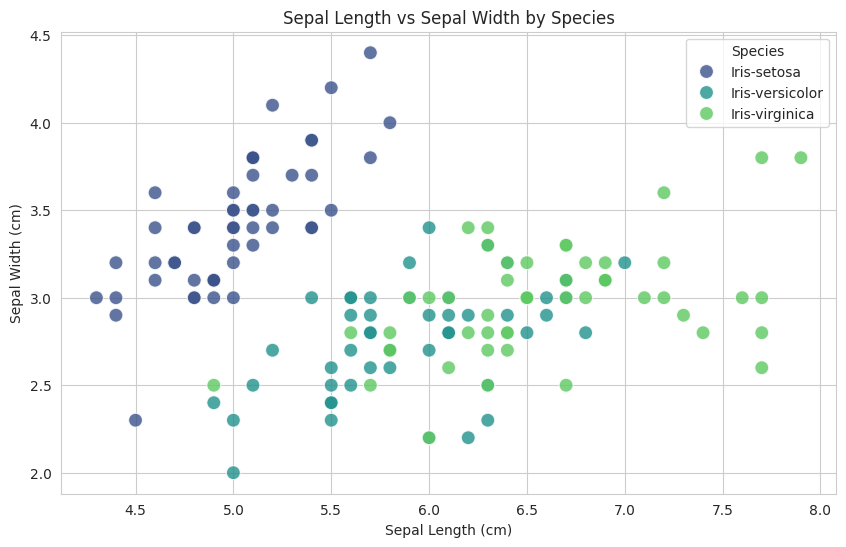

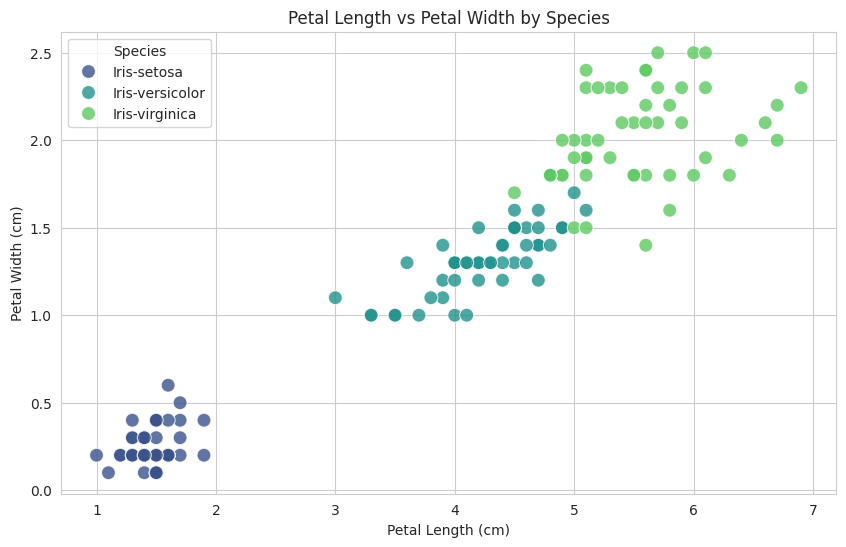

Generating Pair Plot (this may take a moment)...


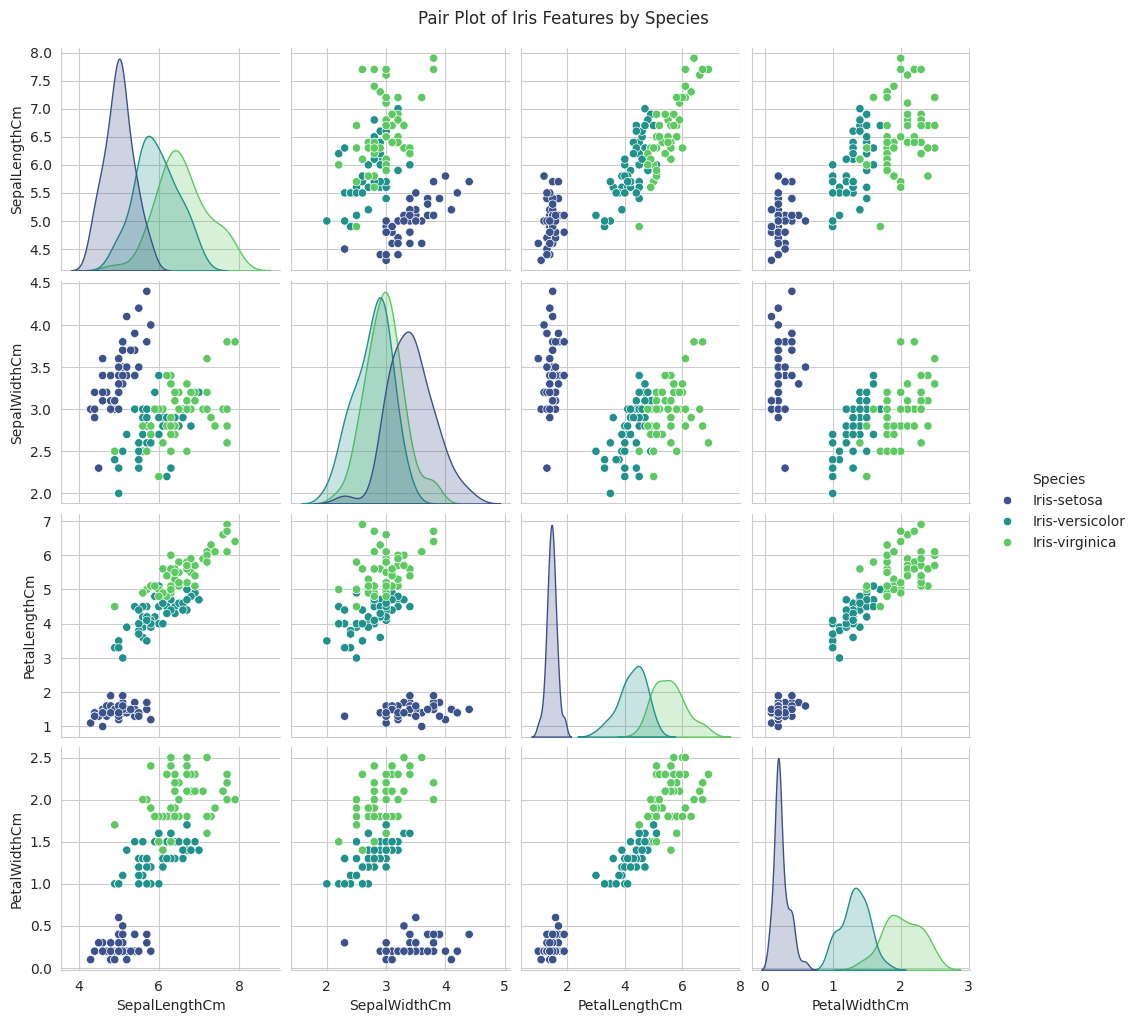

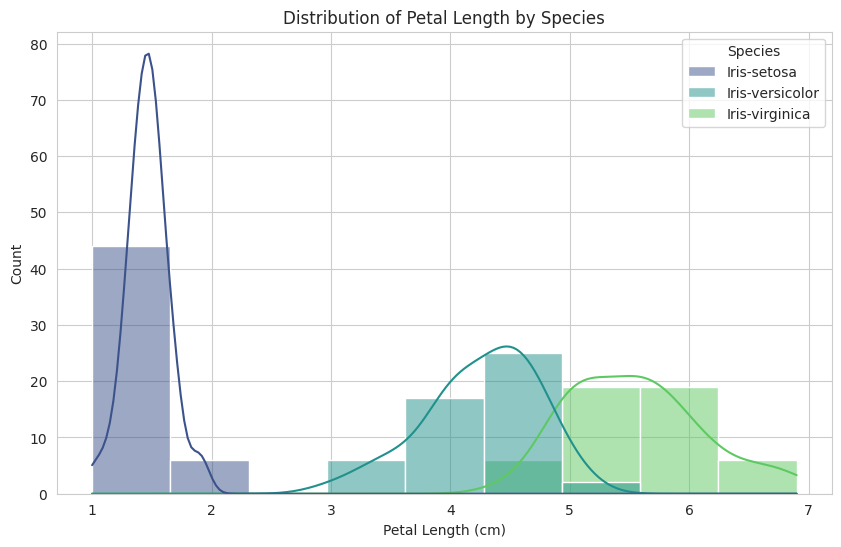

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

# Prepare data for plotting (using the iris_df_selected which excludes 'Id')
plot_df = iris_df_selected.copy()

print("Generating visualizations...")

# Visualization 1: Scatter plot of Sepal Length vs Sepal Width, colored by Species
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='Species', data=plot_df, palette='viridis', s=100, alpha=0.8)
plt.title('Sepal Length vs Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.show()

# Visualization 2: Scatter plot of Petal Length vs Petal Width, colored by Species
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm', hue='Species', data=plot_df, palette='viridis', s=100, alpha=0.8)
plt.title('Petal Length vs Petal Width by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.show()

# Visualization 3: Pair Plot to show relationships between all features
# This visualization is very comprehensive and helps identify patterns easily.
print("Generating Pair Plot (this may take a moment)...")
sns.pairplot(plot_df, hue='Species', palette='viridis')
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02) # Adjust suptitle position
plt.show()

# Visualization 4 (Optional, if needed): Distribution of a single feature using a histogram/KDE plot
# This can be useful to see the distribution of a single feature for each species.
plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df, x='PetalLengthCm', hue='Species', kde=True, palette='viridis')
plt.title('Distribution of Petal Length by Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Count')
plt.show()

## 6. Model Training and Evaluation (Confusion Matrix)

Data split into training and testing sets.
Training set shape: (105, 4)
Testing set shape: (45, 4)
Logistic Regression model trained.


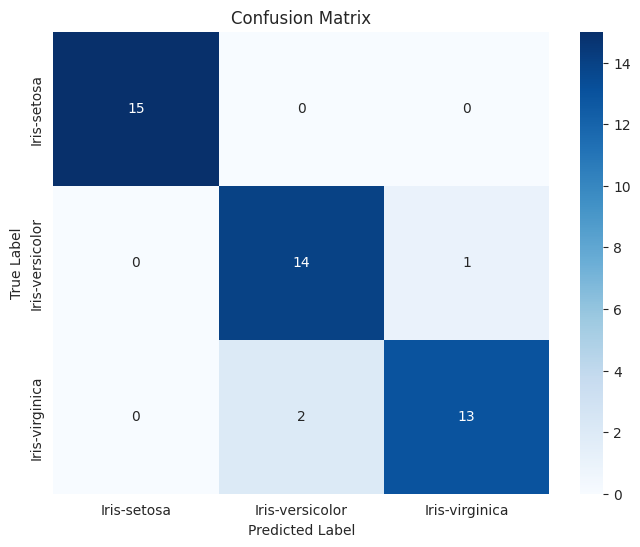


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      0.93      0.90        15
 Iris-virginica       0.93      0.87      0.90        15

       accuracy                           0.93        45
      macro avg       0.93      0.93      0.93        45
   weighted avg       0.93      0.93      0.93        45



In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Define features (X) and target (y)
X = iris_df_selected.drop('Species', axis=1)
y = iris_df_selected['Species']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Data split into training and testing sets.")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Train a Logistic Regression model
# We set max_iter to prevent a convergence warning with the default solver
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display Classification Report for more detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## 8. Compare with Random Forest Classifier

Training Random Forest Classifier...
Random Forest Classifier trained successfully.

Random Forest Accuracy: 0.8889

Random Forest Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.78      0.93      0.85        15
 Iris-virginica       0.92      0.73      0.81        15

       accuracy                           0.89        45
      macro avg       0.90      0.89      0.89        45
   weighted avg       0.90      0.89      0.89        45



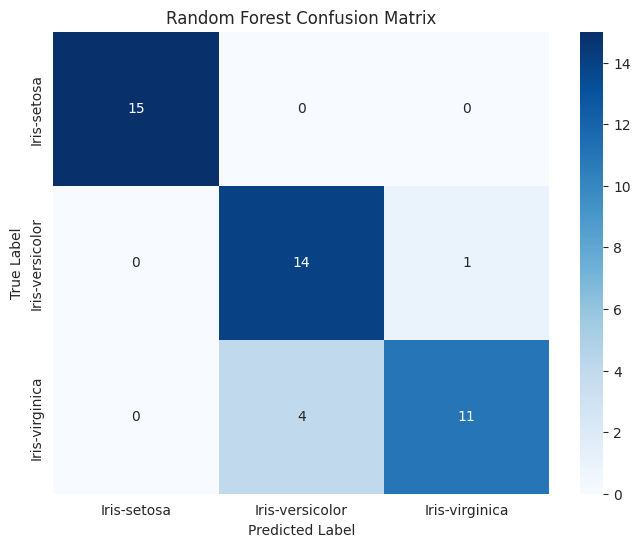

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Training Random Forest Classifier...")

# Initialize and train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # n_estimators is the number of trees in the forest
rf_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Accuracy: {accuracy_rf:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Generate and display Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 10. Hyperparameter Tuning for Random Forest Classifier

Performing hyperparameter tuning for Random Forest Classifier...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Hyperparameter tuning complete.

Best parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}
Best cross-validation accuracy: 0.9619

Best Random Forest Test Accuracy: 0.9111

Best Random Forest Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45



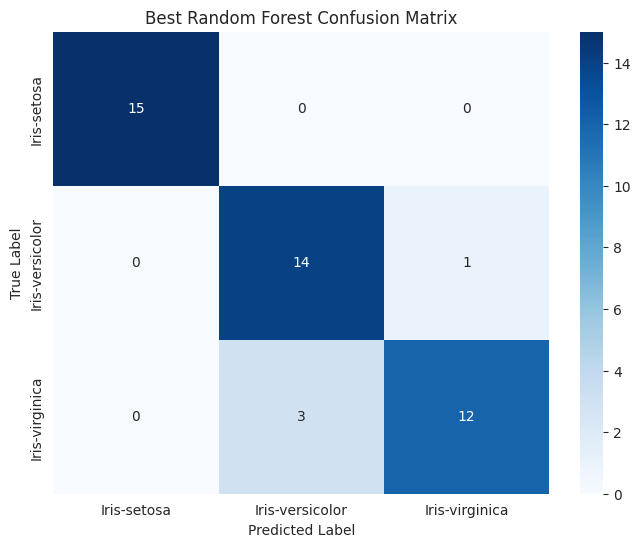

In [15]:
from sklearn.model_selection import GridSearchCV

print("Performing hyperparameter tuning for Random Forest Classifier...")

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize a Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning complete.")

# Print the best parameters and best score
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Get the best Random Forest model
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_best_rf = best_rf_model.predict(X_test)

# Evaluate the best Random Forest model
accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
print(f"\nBest Random Forest Test Accuracy: {accuracy_best_rf:.4f}")

print("\nBest Random Forest Classification Report:")
print(classification_report(y_test, y_pred_best_rf))

# Generate and display Confusion Matrix for the best Random Forest model
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_rf_model.classes_, yticklabels=best_rf_model.classes_)
plt.title('Best Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 9. Additional Visualizations: Bar, Line, and Bubble Graphs

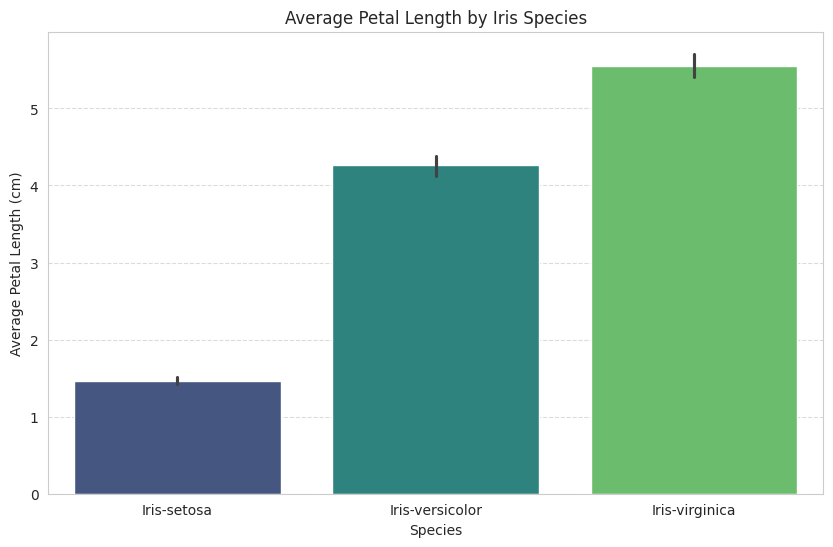

In [14]:
# Bar Graph: Average Petal Length by Species
plt.figure(figsize=(10, 6))
sns.barplot(x='Species', y='PetalLengthCm', data=plot_df, palette='viridis', hue='Species', legend=False)
plt.title('Average Petal Length by Iris Species')
plt.xlabel('Species')
plt.ylabel('Average Petal Length (cm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

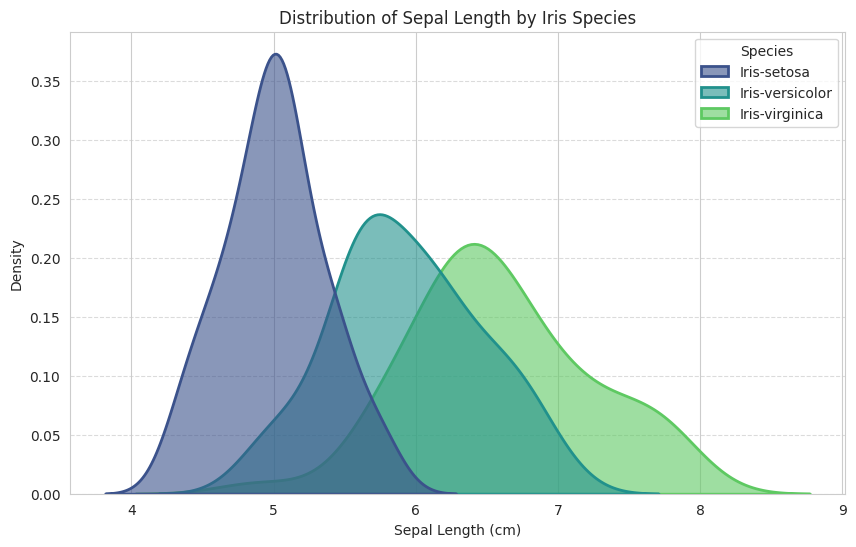

In [12]:
# Line Graph: Distribution of Sepal Length by Species (using KDE plot)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=plot_df, x='SepalLengthCm', hue='Species', fill=True, palette='viridis', alpha=0.6, linewidth=2)
plt.title('Distribution of Sepal Length by Iris Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

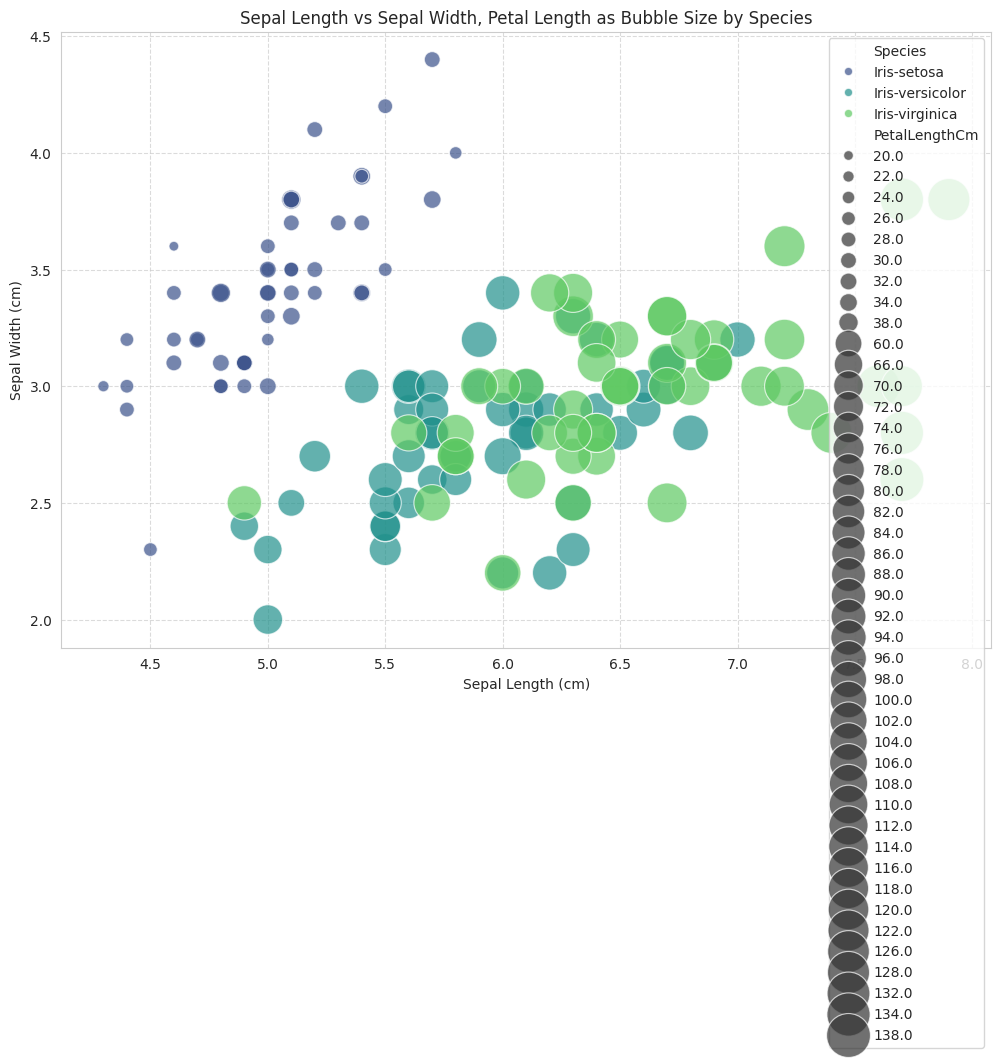

In [13]:
# Bubble Graph: Sepal Length vs Sepal Width, with Petal Length as bubble size
# We'll normalize PetalLengthCm to scale the bubble sizes appropriately for visualization.
# Let's scale PetalLengthCm to be visible, e.g., multiply by a factor.
scaled_petal_length = plot_df['PetalLengthCm'] * 20 # Adjust factor as needed for visibility

plt.figure(figsize=(12, 8))
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='Species', size=scaled_petal_length, sizes=(50, 1000),
                data=plot_df, palette='viridis', alpha=0.7, legend='full')
plt.title('Sepal Length vs Sepal Width, Petal Length as Bubble Size by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

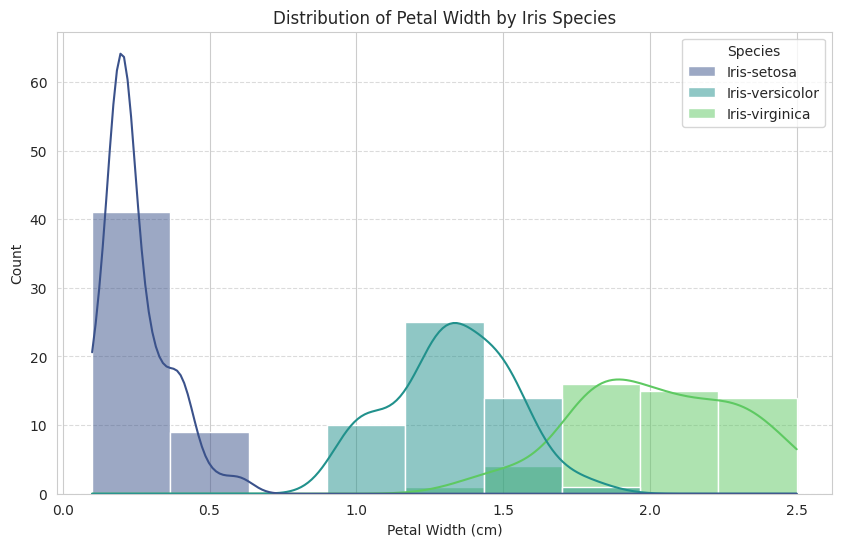

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df, x='PetalWidthCm', hue='Species', kde=True, palette='viridis')
plt.title('Distribution of Petal Width by Iris Species')
plt.xlabel('Petal Width (cm)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 7. Feature Importance Plot

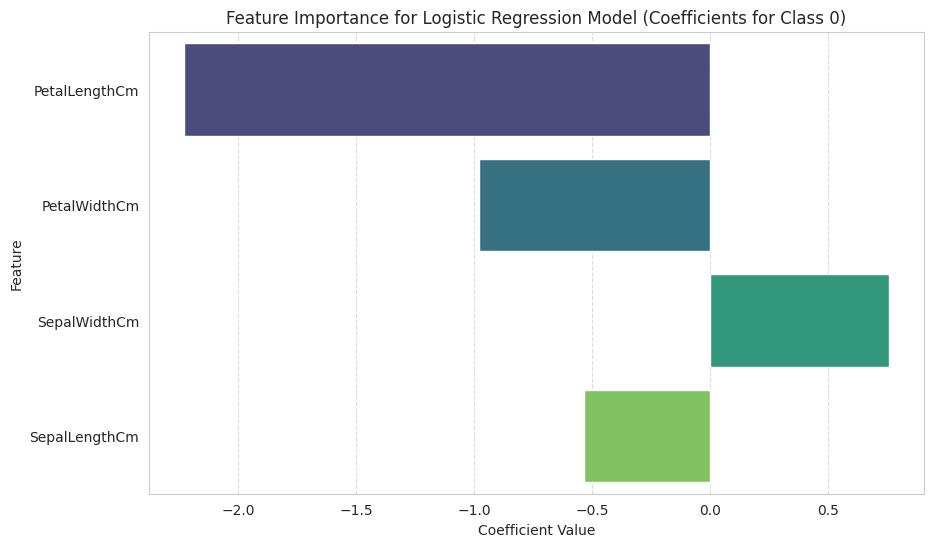

Features sorted by their importance (absolute coefficient value) for class 0:


,Feature,Importance
0,PetalLengthCm,-2.227863
1,PetalWidthCm,-0.979102
2,SepalWidthCm,0.756772
3,SepalLengthCm,-0.533397


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances (coefficients) from the Logistic Regression model
# For multi-class classification, LogisticRegression.coef_ is a 2D array (n_classes, n_features).
# To simplify for plotting, we can take the coefficients for one class or an average/sum.
# For interpretation in a multi-class setting, usually the absolute magnitude of coefficients across classes is considered, or for a specific class vs. rest.
# Here, we'll plot the coefficients of the first class as a representation.
# A more rigorous approach for multi-class importance might involve averaging absolute coefficients or more complex methods.
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0] # Using coefficients of the first class (e.g., Iris-setosa vs rest)
})

# Sort the features by their absolute importance
feature_importances['Abs_Importance'] = abs(feature_importances['Importance'])
feature_importances = feature_importances.sort_values(by='Abs_Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance for Logistic Regression Model (Coefficients for Class 0)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Features sorted by their importance (absolute coefficient value) for class 0:")
display(feature_importances[['Feature', 'Importance']].reset_index(drop=True))